In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

from scipy.signal import welch, savgol_filter
from scipy.interpolate import interp1d
from scipy.stats import linregress
from scipy.ndimage import uniform_filter1d

from scipy.io import loadmat
import pickle

In [229]:
import PSD_utils
import capillary_wave_analysis as cwa  
import bis_bic as bisbic 

In [337]:
# user settings
CSV_DIR      = "/disk/hyk049/H2O_ctr_px_csv_numbers/"
FS_DHM       = 115200.0  
# FB_LOW       = 50  
FB_LOW       = 150
FB_HIGH      = 57_000    
# FB_HIGH_MAX  = 16000.0 
WELCH_SEGS   = 100       
SAVE_PLOTS   = False
SHOW_INERTIAL_SEGMENT = True

sigma   = cwa.surf_ten
rho     = cwa.density
h       = cwa.h
L       = cwa.L
km      = cwa.km


def dwdk(k):
    """Derivative dω/dk for general capillary dispersion."""
    # ω = sqrt(A * k^3 * tanh(kh)), A = σ/ρ
    A  = (sigma/rho)
    th = np.tanh(k*h)
    sech2 = 1.0/np.cosh(k*h)**2
    G  = k**3 * th
    w  = np.sqrt(A*G) + 1e-30  # avoid zero
    dG = 3*k**2*th + k**3*(sech2*h)
    return (A * dG) / (2.0*w)

def df_dk_from_k(k):
    """
    Analytical df/dk for capillary-dominant dispersion:
        ω^2 = (σ/ρ) k^3 tanh(kh)
        f = ω / (2π)
        df/dk = (1/(4π ω)) d(ω^2)/dk
    """
    kh = k * h
    tanh_kh  = np.tanh(kh)
    sech2_kh = 1.0 / np.cosh(kh)**2
    omega    = np.sqrt((sigma/rho) * k**3 * tanh_kh)
    domega2_dk = (sigma/rho) * (3*k**2*tanh_kh + k**3*sech2_kh*h)
    with np.errstate(divide="ignore", invalid="ignore"):
        df_dk = domega2_dk / (4*np.pi*omega)  # df/dk = (1/2π) * dω/dk
        df_dk[~np.isfinite(df_dk)] = 0.0
    return df_dk

def welch_psd_k(z_um, fs):
    """
    return wavenumber and PSD in k
    """
    n = len(z_um)
    # target_segments = 100
    target_segments = 30
    nperseg = max(256, int(2*n/(target_segments+1))) #window size, 50% overlap
    if nperseg % 2:  
        nperseg -= 1

    f, S_f = welch(z_um, fs=fs, window='hann', nperseg=nperseg, noverlap=nperseg//2,
                return_onesided=True, scaling='density')
    # print(f"f[0]: {f[0]}")

    if f.size and f[0] == 0.0:
        f, S_f = f[1:], S_f[1:]

    k = cwa.get_wavenumbers(f)        
    #df_dk = 1.0 / np.gradient(k, f)
    df_dk = df_dk_from_k(k)
    S_k = S_f * np.abs(df_dk)

    return k, S_k

def inertial_range_mask(k, Sk,
                        smooth=False,
                        smooth_win=21, smooth_poly=2,
                        min_pts=10,
                        slope_bounds=(-8.0, -1.0),
                        prefer_longer=False,
                        length_metric="logx",
                        length_weight=1e-3):

    k = np.asarray(k)
    Sk = np.asarray(Sk)
    n = k.size

    logk = np.log10(k + 1e-30)
    logS = np.log10(np.maximum(Sk, np.finfo(float).tiny))


    if smooth:
        win = max(5, int(smooth_win))
        if win % 2 == 0:
            win += 1
        if win >= n:
            win = n - 1 if (n % 2 == 0) else n
        if win < 3:
            win = 3
        try:
            logS_s = savgol_filter(logS, window_length=win, polyorder=min(smooth_poly, 3))
        except Exception:
            logS_s = logS.copy()
    else:
        logS_s = logS

    x=logk
    y=logS_s

    X  = np.r_[0.0, np.cumsum(x)]
    Y  = np.r_[0.0, np.cumsum(y)]
    X2 = np.r_[0.0, np.cumsum(x*x)]
    Y2 = np.r_[0.0, np.cumsum(y*y)]
    XY = np.r_[0.0, np.cumsum(x*y)]

    def seg_stats(i, j):
        m  = j - i + 1
        Sx = X[j+1]-X[i];   Sy = Y[j+1]-Y[i]
        Sxx= X2[j+1]-X2[i]; Syy= Y2[j+1]-Y2[i]
        Sxy= XY[j+1]-XY[i]
        denx = m*Sxx - Sx*Sx
        deny = m*Syy - Sy*Sy
        den  = np.sqrt(max(denx, 0.0) * max(deny, 0.0))
        if den <= 0:
            r2 = -np.inf
            slope = np.nan
        else:
            r   = (m*Sxy - Sx*Sy) / den
            r2  = r*r
            slope = (m*Sxy - Sx*Sy) / max(denx, 1e-300)
        return m, slope, r2
    
    best = (-np.inf, None, None, None)
    for i in range(0, n - (min_pts - 1)):
        for j in range(i + (min_pts - 1), n - 1):
            m, slope, r2 = seg_stats(i, j)
            if np.isfinite(slope) and slope_bounds is not None:
                lo, hi = slope_bounds
                if not (lo <= slope <= hi):
                    continue
            
            if prefer_longer:
                if length_metric == "logx":
                    length = max(x[j] - x[i], 0.0)  # log length
                else:
                    length = max(10**x[j] - 10**x[i], 0.0)
                score = r2 + length_weight * length
            else:
                score = r2

            if score > best[0]:
                best = (score, i, j, slope)
        j = n - 1
        m, slope, r2 = seg_stats(i, j)
        if np.isfinite(slope) and slope_bounds is not None:
            lo, hi = slope_bounds
            if not (lo <= slope <= hi):
                pass
            else:
                if prefer_longer:
                    if length_metric == "logx":
                        length = max(x[j] - x[i], 0.0)
                    else:
                        length = max(10**x[j] - 10**x[i], 0.0)
                    score = r2 + length_weight * length
                else:
                    score = r2
                if score > best[0]:
                    best = (score, i, j, slope)
                    
                    
    score_best, i_best, j_best, slope_best = best
    if i_best is None:
        return np.zeros(n, dtype=bool), np.nan, (None, None)

    if not (score_best > 0.95):
        return np.zeros(n, dtype=bool), np.nan, -np.inf

    mask = np.zeros(n, dtype=bool)
    mask[i_best:j_best+1] = True
    return mask, float(slope_best),score_best

def slope_over_mask(k, Sk, mask):
    if not np.any(mask):
        return np.nan
    x = np.log10(k[mask])
    y = np.log10(np.maximum(Sk[mask], np.finfo(float).tiny))
    return linregress(x, y).slope  

def deep_water_mask_for(k):
    return k > 23800     # k > (1.0/h)

def compute_delta_mu_and_metrics(t, z_um, fs):
    """
    For a single time series:
    - bicoherence grid (authors' wavelet method)
    - NRB curve γ(k) (authors' get_nrb)
    - eigenmode spacing Δω(k) ≈ k_m dω/dk
    - δ_n = γ / Δω on the bicoherence frequency grid
    - global δ_μ 
    - PSD-derived cascade terminus and slopes
    """
    fb_high = float(min(FB_HIGH, 0.9*fs/2.0))

    # 1) Bicoherence 
    f_bico, Bi_spec, Bico = bisbic.wav_bicoherence(
        z_um.astype(float), t.astype(float), fs, fb_low=FB_LOW, fb_high=fb_high, scales=None, Ns=2**10, wavelet='cgau1'
    ) 

    # 2）amplitude
    dt = 1.0 / fs
    n = len(z_um)
    # target_segments = 100
    target_segments = 30
    
    nperseg = max(256, int(2*n/(target_segments+1)))  
    if nperseg % 2:
        nperseg -= 1
    f, S_f = welch(z_um, fs=fs, window="hann", nperseg=2**12, noverlap=2048, detrend=False,
                return_onesided=True, scaling="density")
    #S_f = uniform_filter1d(S_f,size=4,mode='nearest',origin=0)

    if f.size and f[0] == 0.0:
        f   = f[1:]
        S_f = S_f[1:]

    magZ = np.sqrt(S_f/(2*dt))
    
    # kv: wavenumbers, NRB: NRB on f grid
    kv, NRB = cwa.get_nrb(f, magZ, no_strong=True)
    NRB = interp1d(f, NRB)(f_bico)
    kv = cwa.get_wavenumbers(f_bico)


    # 4) Eigenmode grid spacing in angular frequency: Δω ≈ k_m * dω/dk
    #    Convert γ to angular-frequency units if needed
    delta_k = km * dwdk(kv) / (2*np.pi)

    
    # δ_n on the 1D frequency grid
    # Nonlinearity at wavenumber k_n
    delta_n = NRB / (delta_k + 1e-30)  # dimensionless

    # 5) Build δ_μ: b^2-weighted RMS over unique (n,m) pairs
    b2 = (Bico**2).astype(np.float64)
    
    # Tile delta_n to 2D
    dn_row = np.tile(delta_n.reshape(1,-1), (len(delta_n), 1))
    dn_col = dn_row.T
    num = np.tril(dn_row * dn_col * b2).sum()
    den = np.tril(b2).sum() + 1e-30
    delta_mu = np.sqrt(num / den)


    # 6) PSD -> cascade terminus and slopes
    k_psd, S_k = welch_psd_k(z_um, fs)

    # mask = (k_psd >= 4000/1.2) & (k_psd <= 64000*1.2)
    mask = (k_psd >= 10) & (k_psd <= 120_000)   
    
    k_psd = k_psd[mask]
    S_k=S_k[mask]

    # inertial mask
    mask_inertial, slope_full, r2_full = inertial_range_mask(k_psd, S_k)
    
    #slope_full = slope_over_mask(k_psd, S_k, mask_inertial)
    
    # deep slope (k > 1/h)
    mask_deep  = (k_psd > 23800)
    k_psd_deep = k_psd[mask_deep]
    S_k_deep  = S_k[mask_deep]
    mask_deep, slope_deep, r2_deep = inertial_range_mask(k_psd_deep, S_k_deep)
    
    #mask_deep = mask_inertial & deep_water_mask_for(k_psd)
    #slope_deep = slope_over_mask(k_psd, S_k, mask_deep)
    # terminal cascade wavenumber = max k in inertial mask
    
    k_term = np.nan
    if np.any(mask_inertial):
        k_term = float(np.max(k_psd[mask_inertial]))

    print(f"Inertial range slope = {slope_full}, r2={r2_full}, deep range slope ={slope_deep}, r2={r2_deep}")
    return {
        "f_bi": f_bico,
        "bispectrum": Bi_spec,
        "bicoherence": Bico,
        "delta_mu": float(delta_mu),
        "k_term":   float(k_term),
        "slope_full": float(slope_full) if slope_full is not None else np.nan,
        "slope_deep": float(slope_deep) if slope_deep is not None else np.nan,
        "k_psd":         k_psd,
        "S_k":           S_k,
        "mask_inertial": mask_inertial,
        "r2_full":       r2_full, 
        "k_psd_deep":    k_psd_deep,
        "S_k_deep":      S_k_deep,
        "mask_deep":     mask_deep,
        "r2_deep":       r2_deep, 
    }


In [241]:
# file paths
power = ['0p04', '0p07', '0p08', '0p10', '0p15', '0p18', '0p20', '0p25', '0p30', '0p35']
r_all = [13, 11, 10, 12, 13, 5, 11, 13, 19, 14]
sig_all = [40, 7, 30, 37, 31, 29, 31, 10, 6, 5]

file_path = '/disk/hyk049/WT_RomFit'

file_path_all = []

for i, (vpp, rr, sig) in enumerate(zip(power, r_all, sig_all)):
    filename = f"{file_path}/{vpp}/{vpp}vpp_r={rr}_ABN_amp1_sigma{sig}_new.mat"
    file_path_all.append(filename)

In [242]:
with open("/disk/hyk049/WT_RomFit/time.pkl", "rb") as f:
    data = pickle.load(f)

t = data["tt"]
dt = t[1]-t[0]

In [243]:
with open("/disk/hyk049/ALL_psd_diff.pkl", "rb") as f:
    ALL_psd_diff = pickle.load(f)

In [338]:
analysis_data = []
results_FOM = []
results_ROM = []

for file, vpp in zip(file_path_all, power):

    data = loadmat(file)
    EFOM = data['EFOM']
    EROM = data['EROM_opt']

    z_fom = EFOM[100, :]
    z_rom = EROM[100, :]

    n = z_fom.size
    fs = FS_DHM
    t0 = float(t[0])
    # t_uniform = t0 + np.arange(n) / fs

    print(f"{vpp} FOM...")
    metrics_fom = compute_delta_mu_and_metrics(t, z_fom, fs)
    print(f"{vpp} ROM...")
    metrics_rom = compute_delta_mu_and_metrics(t, z_rom, fs)

    results_FOM.append({"power_vpp": vpp, **metrics_fom})
    results_ROM.append({"power_vpp": vpp, **metrics_rom})

    # Store all needed for plotting
    analysis_data.append({
        "vpp": vpp,
        
        "f": metrics_fom["f_bi"],
        "bisp_fom": metrics_fom["bispectrum"],
        "bico_fom": metrics_fom["bicoherence"],
        
        "bisp_rom": metrics_rom["bispectrum"],
        "bico_rom": metrics_rom["bicoherence"],

        "k": metrics_fom["k_psd"],
        "S_fom": metrics_fom["S_k"],
        "S_rom": metrics_rom["S_k"],

        "k_deep_fom": metrics_fom["k_psd_deep"],
        "S_deep_fom": metrics_fom["S_k_deep"],
        "mask_deep_fom": metrics_fom["mask_deep"],

        "k_deep_rom": metrics_rom["k_psd_deep"],
        "S_deep_rom": metrics_rom["S_k_deep"],
        "mask_deep_rom": metrics_rom["mask_deep"],

        "mask_inertial_fom": metrics_fom["mask_inertial"],
        "mask_inertial_rom": metrics_rom["mask_inertial"],
    })

0p04 FOM...
Inertial range slope = -6.941699184336121, r2=0.9903158522819682, deep range slope =nan, r2=-inf
0p04 ROM...
Inertial range slope = -7.788141793834302, r2=0.9708467849909077, deep range slope =nan, r2=-inf
0p07 FOM...
Inertial range slope = -7.447382559661779, r2=0.9802550283721081, deep range slope =nan, r2=-inf
0p07 ROM...
Inertial range slope = -2.663696953847183, r2=0.9778411459394262, deep range slope =nan, r2=-inf
0p08 FOM...
Inertial range slope = -6.727487842336178, r2=0.9936523017524798, deep range slope =nan, r2=-inf
0p08 ROM...
Inertial range slope = -4.029572158742267, r2=0.9832260886541491, deep range slope =nan, r2=-inf
0p10 FOM...
Inertial range slope = -5.854528606693152, r2=0.9929470170773224, deep range slope =-7.79966597970017, r2=0.9758292347709615
0p10 ROM...
Inertial range slope = -6.274569114930538, r2=0.9974428331684778, deep range slope =-4.657935262310158, r2=0.9820687128171337
0p15 FOM...
Inertial range slope = -3.7426281538818778, r2=0.9891339035

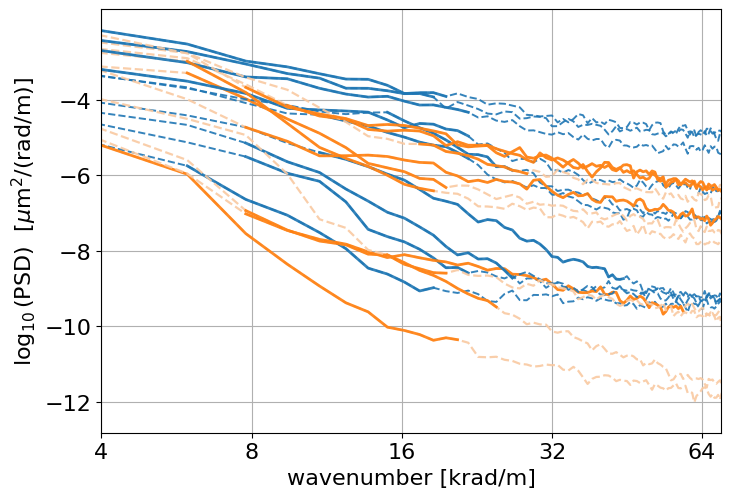

In [ ]:
fig, ax = plt.subplots(figsize=(8.0, 5.5))
plt.rcParams['axes.labelsize'] = 16

for i, d in enumerate(analysis_data):

    k_krad = d["k"] * 1e-3
    log10_psd_fom = np.log10(np.maximum(d["S_fom"], np.finfo(float).tiny))
    log10_psd_rom = np.log10(np.maximum(d["S_rom"], np.finfo(float).tiny))

    # Plot FOM
    ax.plot(k_krad, log10_psd_fom, lw=1.4, color="#1f76b47a", ls="--", alpha=0.9)

    # Plot ROM
    ax.plot(k_krad, log10_psd_rom, lw=1.6, color="#f9c9a1", ls="--", alpha=0.9)

    # Optional: inertial segment (FOM only)
    if SHOW_INERTIAL_SEGMENT and np.any(d["mask_inertial_fom"]):
        ax.plot(k_krad[d["mask_inertial_fom"]], log10_psd_fom[d["mask_inertial_fom"]], lw=2.0, color="#1f77b4", alpha=0.9)
    
    if SHOW_INERTIAL_SEGMENT and np.any(d["mask_inertial_rom"]):
        ax.plot(k_krad[d["mask_inertial_rom"]], log10_psd_rom[d["mask_inertial_rom"]], lw=2.0, color="#ff7f0e", alpha=0.9)

    # # Optional: deep region
    # if np.any(d["mask_deep_fom"]):
    #     k_deep = d["k_deep_fom"] * 1e-3
    #     log_deep = np.log10(np.maximum(d["S_deep_fom"], np.finfo(float).tiny))

    #     ax.plot(k_deep[d["mask_deep_fom"]], log_deep[d["mask_deep_fom"]], lw=2.8, color="#d62728", alpha=0.5)
    
log2_xticks = np.array([4, 8, 16, 32, 64], dtype=float)
ax.set_xscale('log', base=2)
# ax.set_xlim(log2_xticks.min()/1.3, log2_xticks.max()*1.3)
ax.set_xlim(5, 70)
ax.set_xticks(log2_xticks)
ax.set_xticklabels([str(int(x)) for x in log2_xticks])

ax.tick_params(axis='both', labelsize=16)
ax.set_yticks([-12, -10, -8, -6, -4]) 

ax.set_xlabel("wavenumber [krad/m]")
ax.set_ylabel(r"$\log_{10}(\mathrm{PSD})$  [$\mu$m$^2$/(rad/m)]")

# ax.legend()
plt.grid(True)
plt.show()

In [348]:
# fixed wavenumber range
kmin_FOM, kmax_FOM = 8, 32
kmin_ROM, kmax_ROM = 16, 48

inertial_range = [[[6,16], [6,16]], [[4,13], [4,16]], [[4,16], [4,16]], [[12,32], [12,32]], [[6,24],[14,48]],
                  [[6,16], [10,48]], [[8,30], [8,30]], [[8,48], [16,48]], [[8,48], [16,48]], [[8,48], [12,48]] ]

for i, iner in enumerate(inertial_range):

    k = results_FOM[i]["k_psd"]
    S_fom =  results_FOM[i]["S_k"]
    S_rom =  results_ROM[i]["S_k"]
    
    kmin_FOM, kmax_FOM = iner[0]
    kmin_ROM, kmax_ROM = iner[1]

    slope_FOM, r2_FOM = PSD_utils.psd_slope_in_range(k*1e-3, np.log10(S_fom), kmin=kmin_FOM, kmax=kmax_FOM)
    slope_ROM, r2_ROM = PSD_utils.psd_slope_in_range(k*1e-3, np.log10(S_rom), kmin=kmin_ROM, kmax=kmax_ROM)

    # save slopes
    results_FOM[i]["slope_full"] = slope_FOM
    results_ROM[i]["slope_full"] = slope_ROM
    
    # Masks for FOM and ROM
    mask_FOM = (k >= kmin_FOM*1e3) & (k <= kmax_FOM*1e3)
    mask_ROM = (k >= kmin_ROM*1e3) & (k <= kmax_ROM*1e3)

    k_fit_FOM = k[mask_FOM]
    k_fit_ROM = k[mask_ROM]
    
    analysis_data[i]["mask_inertial_fom"] = mask_FOM
    analysis_data[i]["mask_inertial_rom"] = mask_ROM
    

In [325]:
print(slope_FOM)
print(slope_ROM)

-2.24152250786422
-2.4443503582082355


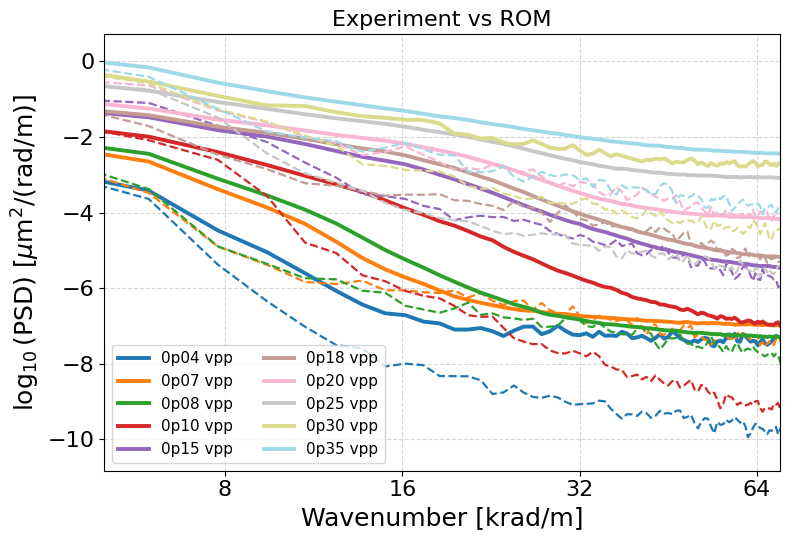

In [328]:
fig, ax = plt.subplots(figsize=(8.0, 5.5))
plt.rcParams['axes.labelsize'] = 16

# Create consistent color map across all cases
colors = plt.cm.tab20(np.linspace(0, 1, len(analysis_data)))

for i, d in enumerate(analysis_data):

    k_krad = d["k"] * 1e-3
    log10_psd_fom = np.log10(np.maximum(d["S_fom"], np.finfo(float).tiny))
    log10_psd_rom = np.log10(np.maximum(d["S_rom"], np.finfo(float).tiny))

    label_str = str(d["vpp"]).rstrip('.')
    
    psd_diff = ALL_psd_diff[label_str]

    # FOM (bold solid)
    ax.plot(k_krad, log10_psd_fom + psd_diff, color=colors[i], lw=2.8, linestyle='-', label=f'{label_str} vpp')

    # ROM (dashed, same color)
    ax.plot(k_krad, log10_psd_rom + psd_diff, color=colors[i], lw=1.6, linestyle='--')

    # Optional: deep region highlight (FOM)
    # if np.any(d["mask_deep_fom"]):
    #     k_deep = d["k_deep_fom"] * 1e-3
    #     log_deep = np.log10(np.maximum(d["S_deep_fom"], np.finfo(float).tiny))

    #     ax.plot(
    #         k_deep[d["mask_deep_fom"]], log_deep[d["mask_deep_fom"]], lw=2.8, color=colors[i], alpha=0.4
    #     )

# Axis formatting (match original style)
log2_xticks = np.array([4, 8, 16, 32, 64], dtype=float)

ax.set_xscale('log', base=2)
ax.set_xlim(log2_xticks.min() / 1.2, log2_xticks.max() * 1.2)
ax.set_xticks(log2_xticks)
ax.set_xticklabels([str(int(x)) for x in log2_xticks], fontsize=16)

ax.tick_params(axis='both', labelsize=16)
ax.grid(True, which='both', ls='--', alpha=0.5)

ax.set_xlim(5, 70)
# ax.set_yticks([-12, -10, -8, -6, -4])
ax.set_yticks([-10, -8, -6, -4, -2, 0])

ax.set_xlabel("Wavenumber [krad/m]", fontsize=18)
ax.set_ylabel(r"$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]", fontsize=18)
ax.set_title("Experiment vs ROM", fontsize=16)

ax.legend(ncol=2, fontsize=11, loc='best')

plt.tight_layout()
plt.show()

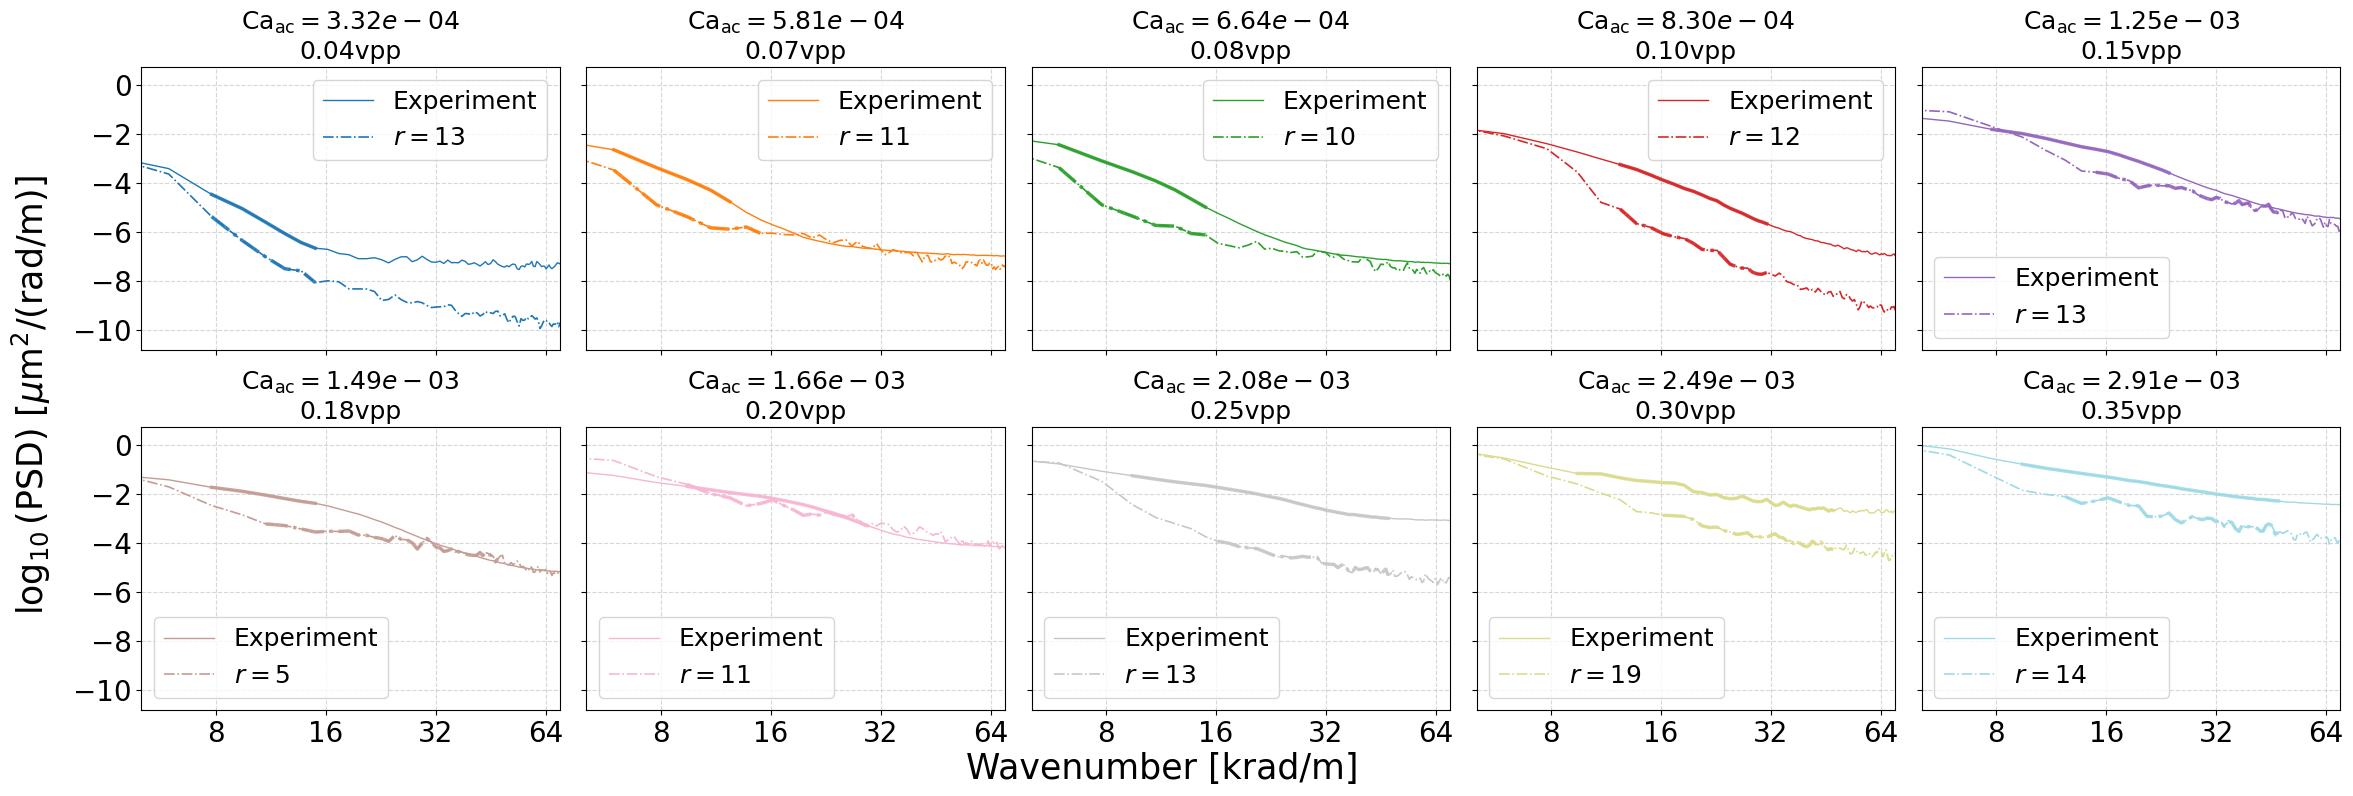

In [349]:
# Acoustic capillary number
Ca_all = np.array([3.32, 5.81, 6.64, 8.30, 12.45, 14.94, 16.60, 20.75, 24.90, 29.05]) * 1e-4
vpp_all = ['0.04vpp', '0.07vpp', '0.08vpp', '0.10vpp', '0.15vpp', '0.18vpp', '0.20vpp', '0.25vpp', '0.30vpp', '0.35vpp']

fig, axes = plt.subplots(2, 5, figsize=(24, 8), sharex=True, sharey=True)
axes_flat = axes.flatten()

plt.rcParams['axes.labelsize'] = 16

# Consistent colormap
colors = plt.cm.tab20(np.linspace(0, 1, len(analysis_data)))

for i, (ax, d, r_temp, sig_temp, Ca_temp, vpp_temp) in enumerate(
    zip(axes_flat, analysis_data, r_all, sig_all, Ca_all, vpp_all)
):

    k_krad = d["k"] * 1e-3

    log10_psd_fom = np.log10(np.maximum(d["S_fom"], np.finfo(float).tiny))
    log10_psd_rom = np.log10(np.maximum(d["S_rom"], np.finfo(float).tiny))

    label_str = str(d["vpp"]).rstrip('.')
    
    psd_diff = ALL_psd_diff[label_str]

    # FOM (bold solid)
    ax.plot(
        k_krad, log10_psd_fom + psd_diff, color=colors[i], lw=1.0, ls='-', label='Experiment'
    )

    # ROM (dashed, same color)
    ax.plot(
        k_krad, log10_psd_rom + psd_diff, color=colors[i], lw=1.2, ls='-.', label=f'$r={r_temp}$'
    )
    
    if SHOW_INERTIAL_SEGMENT and np.any(d["mask_inertial_fom"]):
        ax.plot(k_krad[d["mask_inertial_fom"]], log10_psd_fom[d["mask_inertial_fom"]] + psd_diff[d["mask_inertial_fom"]],
                lw=2.5, ls='-', color=colors[i], alpha=0.9)
    
    if SHOW_INERTIAL_SEGMENT and np.any(d["mask_inertial_rom"]):
        ax.plot(k_krad[d["mask_inertial_rom"]], log10_psd_rom[d["mask_inertial_rom"]] + psd_diff[d["mask_inertial_rom"]],
                lw=2.5, ls='-.', color=colors[i], alpha=0.9)

    ax.set_xscale('log', base=2)
    ax.tick_params(axis='both', labelsize=20)
    ax.grid(True, which='both', ls='--', alpha=0.5)
    ax.set_title(
        rf'$\mathrm{{Ca}}_{{\mathrm{{ac}}}} = {Ca_temp:.2e}$' + '\n' + f'{vpp_temp}', fontsize=18, 
    )

# Shared ticks/limits (apply once)
log2_xticks = np.array([8, 16, 32, 64], dtype=float)

for ax in axes_flat:
    # ax.set_xlim(log2_xticks.min() / 1.2, log2_xticks.max() * 1.2)
    ax.set_xlim(5, 70)
    ax.set_xticks(log2_xticks)
    ax.set_xticklabels([str(int(x)) for x in log2_xticks])
    ax.legend(fontsize=18, loc='best')
    
# Shared y formatting
for ax in axes_flat:
    ax.set_yticks([-10, -8, -6, -4, -2, 0])
    # ax.set_yticks([-12, -10, -8, -6, -4])

fig.text(0.5, 0.02, 'Wavenumber [krad/m]', ha='center', fontsize=25)
fig.text(
    0.02, 0.5,
    r'$\log_{10}(\mathrm{PSD})$ [$\mu$m$^2$/(rad/m)]',
    va='center', rotation='vertical', fontsize=25
)

plt.tight_layout(rect=[0.04, 0.04, 1, 1])
plt.show()

In [384]:
tab_FOM = pd.DataFrame(results_FOM).sort_values("power_vpp").reset_index(drop=True)  
tab_ROM = pd.DataFrame(results_ROM).sort_values("power_vpp").reset_index(drop=True)  

vpp = ['0p04', '0p07', '0p08', '0p10', '0p15', '0p18', '0p20', '0p25', '0p30', '0p35']
powers = [15.01, 45.4, 57.5, 88, 202.7, 298.8, 344.8, 517.9, 713.9, 1043.4]

vpp_to_power = dict(zip(vpp, powers))

tab_FOM["power_mw"] = tab_FOM["power_vpp"].map(vpp_to_power)
tab_ROM["power_mw"] = tab_ROM["power_vpp"].map(vpp_to_power)

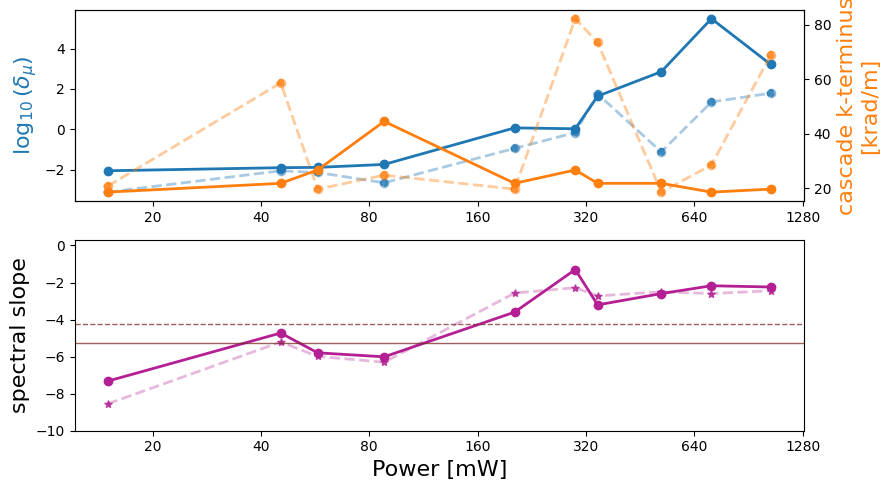

In [385]:
fig3 = plt.figure(figsize=(9, 5))

# Panel (a): log10(delta_mu) and cascade terminus (right axis)
ax1 = fig3.add_subplot(2,1,1)
ax2 = ax1.twinx()

mean_delta_FOM = []
mean_kterm_FOM = []

mean_delta_ROM = []
mean_kterm_ROM = []

for p in powers:
    rows_FOM = tab_FOM[tab_FOM["power_mw"] == p]
    rows_ROM = tab_ROM[tab_ROM["power_mw"] == p]

    # delta_mu scatter
    y_FOM = np.log10(rows_FOM["delta_mu"])
    y_ROM = np.log10(rows_ROM["delta_mu"])
    
    ax1.scatter([p]*len(y_FOM), y_FOM, color="#1f77b4", s=25, alpha=0.7)
    ax1.scatter([p]*len(y_ROM), y_ROM, ls='--', color="#1f76b462", s=25, alpha=0.7)

    # Connect with thin line
    ax1.plot([p]*len(y_FOM), y_FOM, color="#1f77b4", lw=0.8, alpha=0.6)
    ax1.plot([p]*len(y_ROM), y_ROM, ls='--', color="#1f76b462", lw=0.8, alpha=0.6)

    mean_delta_FOM.append(y_FOM.mean())
    mean_delta_ROM.append(y_ROM.mean())

    # k-term scatter
    kterm_FOM = rows_FOM["k_term"] / 1e3
    kterm_ROM = rows_ROM["k_term"] / 1e3
    
    ax2.scatter([p]*len(kterm_FOM), kterm_FOM, color="#ff7f0e", s=25, alpha=0.7)
    ax2.scatter([p]*len(kterm_ROM), kterm_ROM, ls='--', color="#ff7e0e68", s=25, alpha=0.7)

    # Connect with thin line
    ax2.plot([p]*len(kterm_FOM), kterm_FOM, color="#ff7f0e", lw=0.8, alpha=0.6)
    ax2.plot([p]*len(kterm_ROM), kterm_ROM, ls='--', color="#ff7e0e68", lw=0.8, alpha=0.6)

    mean_kterm_FOM.append(kterm_FOM.mean())
    mean_kterm_ROM.append(kterm_ROM.mean())

# connect means
ax1.plot(powers, mean_delta_FOM, '-o', color="#1f77b4", lw=2)
ax1.plot(powers, mean_delta_ROM, '--o', color="#1f76b462", lw=2)

ax2.plot(powers, mean_kterm_FOM, '-o', color="#ff7f0e", lw=2)
ax2.plot(powers, mean_kterm_ROM, '--o', color="#ff7e0e68", lw=2)

ax1.set_ylabel(r"$\log_{10}(\delta_\mu)$", color="#1f77b4")
ax2.set_ylabel("cascade k-terminus\n[krad/m]", color="#ff7f0e")

x_label_power = [0,10,20,40,80,160,320,640,1280]
ax1.set_xscale('log', base=2)
ax1.set_xticks(x_label_power)
ax1.set_xticklabels([str(p) for p in x_label_power])


# Panel (b): spectral slopes (full vs deep)
ax3 = fig3.add_subplot(2,1,2, sharex=ax1)

mean_full_FOM = []
mean_deep_FOM = []

mean_full_ROM = []
mean_deep_ROM = []

for p in powers:
    rows_FOM = tab_FOM[tab_FOM["power_mw"] == p]
    rows_ROM = tab_ROM[tab_ROM["power_mw"] == p]

    # full slope scatter
    full_FOM = rows_FOM["slope_full"]
    full_ROM = rows_ROM["slope_full"]
    ax3.scatter([p]*len(full_FOM), full_FOM, color="#b41f94", s=25, alpha=0.7)
    ax3.scatter([p]*len(full_ROM), full_ROM, marker='*', color="#b41f9450", s=25, alpha=0.7)

    # Connect full slopes
    ax3.plot([p]*len(full_FOM), full_FOM, color="#1f77b4", lw=0.8, alpha=0.6)
    ax3.plot([p]*len(full_ROM), full_ROM, color="#1f76b462", lw=0.8, alpha=0.6)

    mean_full_FOM.append(full_FOM.mean())
    mean_full_ROM.append(full_ROM.mean())

    # # deep slope scatter
    # deep_FOM = rows_FOM["slope_deep"]
    # deep_ROM = rows_ROM["slope_deep"]
    
    # ax3.scatter([p]*len(deep_FOM), deep_FOM, color="#d62728", s=25, alpha=0.7)
    # ax3.scatter([p]*len(deep_ROM), deep_ROM, ls='--', color="#d627276d", s=25, alpha=0.7)

    # Connect deep slopes
    # ax3.plot([p]*len(deep_FOM), deep_FOM, color="#d62728", lw=0.8, alpha=0.6)
    # ax3.plot([p]*len(deep_ROM), deep_ROM, ls='--', color="#d627276d", lw=0.8, alpha=0.6)

    # mean_deep_FOM.append(deep_FOM.mean())
    # mean_deep_ROM.append(deep_ROM.mean())

# connect means
ax3.plot(powers, mean_full_FOM, '-o', color="#b41f94", lw=2)
# ax3.plot(powers, mean_deep_FOM, '-o', color="#d62728", lw=2)

ax3.plot(powers, mean_full_ROM, '--*', color="#b41f9450", lw=2)
# ax3.plot(powers, mean_deep_ROM, '--o', color="#d627276d", lw=2)

# theory lines
ax3.axhline(-21/4, color="#7C2929C1", ls="-", lw=1)
ax3.axhline(-17/4, color="#7C2929C1", ls="--", lw=1)

ax3.set_ylabel("spectral slope")
ax3.set_xlabel("Power [mW]")
ax3.set_ylim(-8.3, 0.3)
ax3.set_yticks([-10,-8,-6,-4,-2,0])

plt.tight_layout()
plt.show()


## **Bispectrum, bicoherence**

In [ ]:
# === 2) WAVELET BISPECTRUM & BICOHERENCE ===================================
# # bispectrum
# f_wav, Bispec_avg = bisbic.wav_bispectrum(
#     z, t, FS,
#     fb_low=FB_LOW, fb_high=FB_HIGH,
#     scales=None,Ns=2**10,wavelet='cgau1',bico=False)
# print("DEBUG window:","Bi.shape=", Bispec.shape, " dtype=", Bispec.dtype)
# Z_bis = np.log10(np.abs(Bispec_avg))  

In [352]:
z_FOM = {}
z_ROM = {}

# load all FOMs/ROMs
for file, vpp in zip(file_path_all, power):

    data = loadmat(file)
    EFOM = data['EFOM']
    EROM = data['EROM_opt']

    z_fom = EFOM[100, :]
    z_rom = EROM[100, :]
    
    z_FOM[vpp] = z_fom
    z_ROM[vpp] = z_rom

In [ ]:
FB_LOW       = 150                   
# FB_HIGH      = 41_000
FB_HIGH      = 57_000               
FS           = 115_200
SAVE_PLOTS   = False                 

PROFILE_F1_HZ = 2500

# Nyquist clamp for upper bound
nyq = 0.5 * FS
FB_HIGH = min(FB_HIGH, 0.49 * FS)

f_wav_ALL = {}
Bi_spec_FOM_ALL = {}
Bi_spec_ROM_ALL = {}
Bico_FOM_ALL = {}
Bico_ROM_ALL = {}

for vpp_temp in power:
    
    print(f"Computing bispec/bico for {vpp_temp}...")
    
    z_F = z_FOM[vpp_temp]
    z_R = z_ROM[vpp_temp]

    # FOM bispectrum and bicoherence
    f_wav, Bi_spec_fom, Bico_fom = bisbic.wav_bicoherence(z_F, t, FS, fb_low=FB_LOW, fb_high=FB_HIGH, scales=None, Ns=2**10, wavelet='cgau1')
    Z_bis_fom = np.log10(Bi_spec_fom)

    # ROM bispectrum and bicoherence
    f_wav, Bi_spec_rom, Bico_rom = bisbic.wav_bicoherence(z_R, t, FS, fb_low=FB_LOW, fb_high=FB_HIGH, scales=None, Ns=2**10, wavelet='cgau1')
    Z_bis_rom = np.log10(Bi_spec_rom)
    
    f_wav_ALL[vpp_temp] = f_wav
    Bi_spec_FOM_ALL[vpp_temp] = Z_bis_fom
    Bi_spec_ROM_ALL[vpp_temp] = Z_bis_rom
    Bico_FOM_ALL[vpp_temp] = Bico_fom
    Bico_ROM_ALL[vpp_temp] = Bico_rom


Computing bispec/bico for 0p04...
Computing bispec/bico for 0p07...
Computing bispec/bico for 0p08...
Computing bispec/bico for 0p10...
Computing bispec/bico for 0p15...
Computing bispec/bico for 0p18...
Computing bispec/bico for 0p20...
Computing bispec/bico for 0p25...
Computing bispec/bico for 0p30...
Computing bispec/bico for 0p35...


In [286]:
# Plot (paper-like colormap)
cmap_paper = LinearSegmentedColormap.from_list(
    'custom_thermal',
    ['#082567', '#235b9c', '#1889c7', '#62b2b6',
     '#b7d8b5', '#eed7b5', '#f4c29c'], N=256)


In [386]:
vpp_temp = '0p30'        # power of interest

f_wav = f_wav_ALL[vpp_temp]
Z_bis_fom = Bi_spec_FOM_ALL[vpp_temp]
Z_bis_rom = Bi_spec_ROM_ALL[vpp_temp]
Bico_fom = Bico_FOM_ALL[vpp_temp]
Bico_rom = Bico_ROM_ALL[vpp_temp]

In [394]:
# Using already computed bispec/bico

vpp_temp = '0p30'        # power of interest
power_temp = vpp_to_power[vpp_temp]

rows_FOM = tab_FOM[tab_FOM["power_mw"] == power_temp].iloc[0]
rows_ROM = tab_ROM[tab_ROM["power_mw"] == power_temp].iloc[0]

f_wav = rows_FOM["f_bi"]
Z_bis_fom = np.log10(np.maximum(rows_FOM["bispectrum"], 1e-12))
Z_bis_rom = np.log10(np.maximum(rows_ROM["bispectrum"], 1e-12))
Bico_fom = rows_FOM["bicoherence"]
Bico_rom = rows_ROM["bicoherence"]

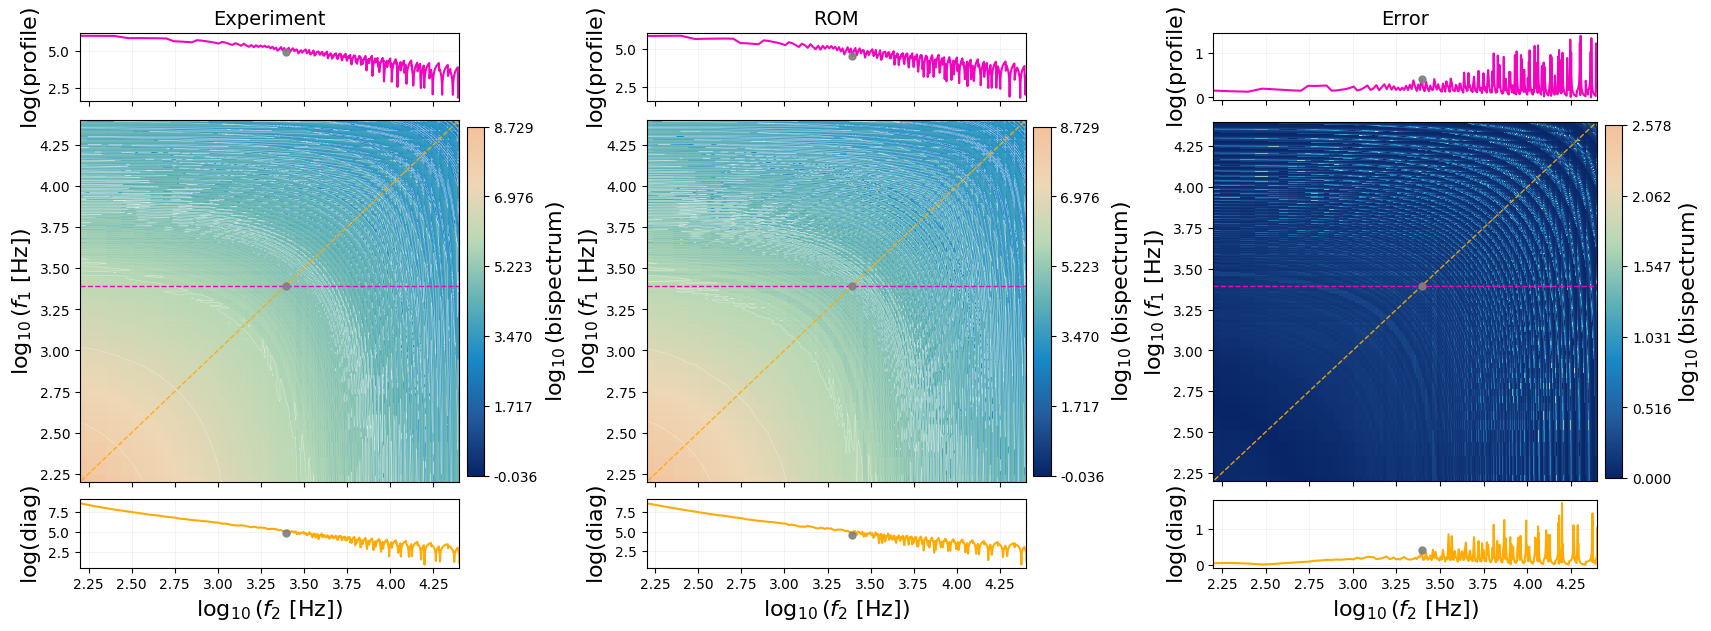

In [395]:
# --- Error ---
Z_err = np.abs(Z_bis_fom - Z_bis_rom)

vmin_main = min(np.min(Z_bis_fom), np.min(Z_bis_rom))
vmax_main = max(np.max(Z_bis_fom), np.max(Z_bis_rom))

vmin_err = np.min(Z_err)
vmax_err = np.max(Z_err)

datasets = [
    ("Experiment", f_wav, Z_bis_fom, (vmin_main, vmax_main)),
    ("ROM", f_wav, Z_bis_rom, (vmin_main, vmax_main)),
    ("Error", f_wav, Z_err, (vmin_err, vmax_err)),
]

fig = plt.figure(figsize=(17, 6.2), constrained_layout=True)
outer_gs = GridSpec(1, 3, figure=fig, wspace=0.2)

for col, (title, f_wav, Z_bis, (vmin, vmax)) in enumerate(datasets):

    gs = GridSpecFromSubplotSpec(
        3, 1,
        height_ratios=[1, 5.3, 1],
        hspace=0.05,
        subplot_spec=outer_gs[col]
    )

    bisp_top = fig.add_subplot(gs[0])
    bisp_mid = fig.add_subplot(gs[1], sharex=bisp_top)
    bisp_bot = fig.add_subplot(gs[2], sharex=bisp_top)

    logf = np.log10(f_wav)

    # --- profile ---
    idx_f1 = np.argmin(np.abs(f_wav - PROFILE_F1_HZ))
    logf_profile = logf[idx_f1]
    profile_trace = Z_bis[idx_f1, :]

    bisp_top.plot(logf, profile_trace, color="#f205bf", lw=1.5)
    bisp_top.plot([logf_profile], [Z_bis[idx_f1, idx_f1]],
                'o', color='gray', ms=5, alpha=0.9)
    bisp_top.set_title(title, fontsize=14)
    bisp_top.set_ylabel(r'$\log(\mathrm{profile})$')
    bisp_top.grid(True, alpha=0.25, lw=0.4)
    bisp_top.tick_params(labelbottom=False)

    # --- bispectrum ---
    if title == "Error":
        cmap_use = cmap_paper
        # cmap_use = 'hot'
    else:
        cmap_use = cmap_paper
        # cmap_use = 'plasma' 

    pc = bisp_mid.pcolormesh(
        logf, logf, Z_bis,
        cmap=cmap_use,
        shading='auto',
        vmin=vmin, vmax=vmax
    )

    # contours only for FOM/ROM
    if title != "Error":
        levels_bis = np.linspace(vmin, vmax, 10)
        bisp_mid.contour(
            logf, logf, Z_bis,
            levels=levels_bis,
            colors='white', linewidths=0.25, alpha=0.7
        )
        
    bisp_mid.set_xlim(2.2, 4.4)
    bisp_mid.set_ylim(2.2, 4.4)

    bisp_mid.plot([logf[0], logf[-1]], [logf[0], logf[-1]],
                '--', color="#ffab03", lw=1, alpha=0.9)
    bisp_mid.axhline(logf_profile, ls='--', color="#f205bf", lw=1.0)

    bisp_mid.set_ylabel(r'$\log_{10}(f_1 \ [\mathrm{Hz}])$')
    bisp_mid.tick_params(labelbottom=False)
    
    bisp_mid.plot([logf_profile], [logf_profile],
                'o', ms=5, color='gray', zorder=5, alpha=0.9)
    

    # --- colorbar ---
    cbar = fig.colorbar(pc, ax=bisp_mid, pad=0.02, fraction=0.046)

    # ticks: min, max, and intermediate points
    n_ticks = 6
    ticks = np.linspace(vmin, vmax, n_ticks)
    cbar.set_ticks(ticks)
    cbar.ax.set_yticklabels([f"{t:.3f}" for t in ticks])

    cbar.set_label(r'$\log_{10}(\mathrm{bispectrum})$')
        

    # --- diagonal ---
    diag_trace = np.diag(Z_bis)
    bisp_bot.plot(logf, diag_trace, color="#ffab03", lw=1.5)
    bisp_bot.grid(True, alpha=0.25, lw=0.4)
    bisp_bot.set_xlabel(r'$\log_{10}(f_2 \ [\mathrm{Hz}])$')
    bisp_bot.set_ylabel(r'$\log(\mathrm{diag})$')

    bisp_bot.plot([logf_profile], [Z_bis[idx_f1, idx_f1]],
                'o', color='gray', ms=5, alpha=0.9)

plt.show()

**Why diagonal?**
The bispectrum is defined as:
$$
B(f_1, f_2) = \mathbb{E} \left[ X(f_1) X(f_2) X^*(f_1 + f_2) \right].
$$
It measures **quadratic phase coupling** ---i.e., whether two frequencies $f_1$ and $f_2$ interact to produce energy at their sum $f_1 + f_2$.

The diagonal corresponds to: 
$$
f_1 = f_2,
$$
so along the diagonal:
$$
B(f,f) = \mathbb{E} \left[ X(f)^2 X^*(2f) \right].
$$

Why is this important?
1. The diagonal captures whether a frequency interact with itself. This directly corresponds to **harmonic generation**: $f+f = 2f$. So the diagonal shows if wave signal at frequency $f$ is generating energy at $2f$ $\rightarrow$ **clear sign of nonlinearity**.

2. Simple interpretation: Instead of scanning a 2D freq. surface, the diagonal gives a 1D summary of:
- energy transfer
- nonlinear self-coupling
- harmonic content

3. Indicator of nonlinear dynamics
For linear processes, bispectrum would be zero everywhere. For nonlinear systems, diagonal often lights up strongly.

4. **Off-diagonal**: interaction between \textit{different} frequencies.
- diagoanl: harmonics
- off-diagonal: cross-frequency coupling


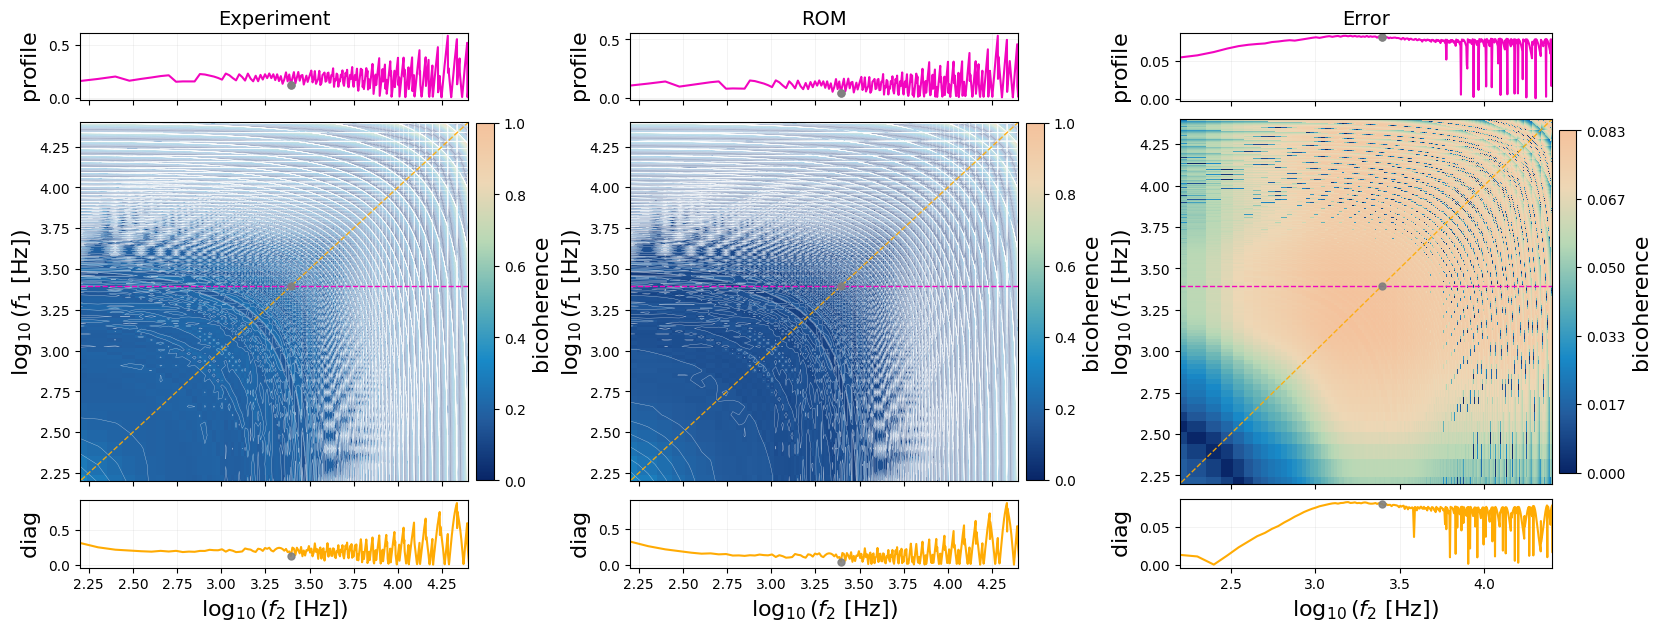

In [396]:
# Bicoherence plots
# --- Error ---
Z_bic_err = np.abs(Bico_fom - Bico_rom)

datasets = [
    ("Experiment", Bico_fom),
    ("ROM", Bico_rom),
    ("Error", Z_bic_err),
]

fig = plt.figure(figsize=(16.5, 6.2), constrained_layout=True)
outer_gs = GridSpec(1, 3, figure=fig, wspace=0.2)

for col, (title, Z_bic) in enumerate(datasets):

    gs = GridSpecFromSubplotSpec(
        3, 1,
        height_ratios=[1, 5.3, 1],
        hspace=0.05,
        subplot_spec=outer_gs[col]
    )

    bic_top = fig.add_subplot(gs[0])
    bic_mid = fig.add_subplot(gs[1], sharex=bic_top)
    bic_bot = fig.add_subplot(gs[2], sharex=bic_top)

    # --- Profile ---
    profile_trace_bic = Z_bic[idx_f1, :]

    bic_top.plot(logf, profile_trace_bic, color="#f205bf", lw=1.5)
    bic_top.plot([logf_profile], [Z_bic[idx_f1, idx_f1]],
                'o', color='gray', ms=5, alpha=0.9)
    bic_top.set_title(title, fontsize=14)
    bic_top.set_ylabel(r'$\mathrm{profile}$')
    bic_top.grid(True, alpha=0.25, lw=0.4)
    bic_top.tick_params(labelbottom=False)
    
    bic_top.plot([logf_profile], [Z_bic[idx_f1, idx_f1]],
                'o', color='gray', ms=5, alpha=0.9)

    # --- Bicoherence ---
    if title != "Error":
        cmap_use = cmap_paper
        vmin, vmax = 0, 1   # standard for bicoherence
    else:
        # cmap_use = 'hot'
        cmap_use = cmap_paper
        vmin, vmax = np.min(Z_bic_err), np.max(Z_bic_err)

    pc2 = bic_mid.pcolormesh(
        logf, logf, Z_bic,
        cmap=cmap_use,
        shading='auto',
        vmin=vmin, vmax=vmax
    )

    # contours (optional skip for error)
    if title != "Error":
        levels_bic = np.arange(0, 1, 0.025)
        bic_mid.contour(logf, logf, Z_bic,
                        levels=levels_bic,
                        colors='white', linewidths=0.25, alpha=0.7)

    bic_mid.set_xlim(2.2, 4.4)
    bic_mid.set_ylim(2.2, 4.4)

    # ticks = [2, 3, 4]
    # bic_mid.set_xticks(ticks)
    # bic_mid.set_yticks(ticks)

    bic_mid.plot([logf[0], logf[-1]], [logf[0], logf[-1]],
                '--', color="#ffab03", lw=1, alpha=0.9)

    bic_mid.axhline(logf_profile, ls='--', color="#f205bf", lw=1.0)
    bic_mid.plot([logf_profile], [logf_profile],
                'o', ms=5, color='gray', zorder=5, alpha=0.9)

    bic_mid.set_ylabel(r'$\log_{10}(f_1 \ [\mathrm{Hz}])$')
    bic_mid.tick_params(labelbottom=False)
    
    bic_mid.plot([logf_profile], [Z_bic[idx_f1, idx_f1]],
                'o', color='gray', ms=5, alpha=0.9)

    # --- Colorbar ---
    cbar2 = fig.colorbar(pc2, ax=bic_mid, pad=0.02, fraction=0.046)
    ticks2 = np.linspace(vmin, vmax, 6)
    cbar2.set_ticks(ticks2)
    cbar2.set_label('bicoherence')
    
    if title == "Error":
        cbar2.set_ticklabels([f"{t:.3f}" for t in ticks2]) 


    # --- Diagonal ---
    diag_trace_bic = np.diag(Z_bic)

    bic_bot.plot(logf, diag_trace_bic, color="#ffab03", lw=1.5)
    bic_bot.grid(True, alpha=0.25, lw=0.4)
    bic_bot.set_ylabel(r'$\mathrm{diag}$')
    bic_bot.set_xlabel(r'$\log_{10}(f_2 \ [\mathrm{Hz}])$')

    bic_bot.plot([logf_profile], [Z_bic[idx_f1, idx_f1]],
                'o', color='gray', ms=5, alpha=0.9)

    # sync limits
    bic_top.set_xlim(bic_mid.get_xlim())


plt.show()